# 6CS012 - Worksheet 6: Image Classification with CNN and Transfer Learning
**Practical Aspects of Training CNN for Image Classification**

---
## Section 2.1 - Data Understanding and Visualizations

In [ ]:
import os
import random
import zipfile
from PIL import Image, UnidentifiedImageError

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    Activation,
    GlobalAveragePooling2D,
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Extract dataset from zip file
ZIP_FILE_NAME = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon.zip'
EXTRACTED_DIR = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon'

if not os.path.exists(EXTRACTED_DIR):
    try:
        with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
            zip_ref.extractall(EXTRACTED_DIR)
        print(f"Successfully extracted '{ZIP_FILE_NAME}' to '{EXTRACTED_DIR}'")
    except FileNotFoundError:
        print(f"Error: '{ZIP_FILE_NAME}' not found. Please upload your dataset.")
    except Exception as e:
        print(f"Error extracting file: {e}")
else:
    print(f"Directory '{EXTRACTED_DIR}' already exists. Skipping extraction.")

Successfully unzipped '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon.zip' to '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon'


In [ ]:
# Define dataset path and load class names
TRAIN_DIR = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))

if not CLASS_NAMES:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(CLASS_NAMES)} classes: {CLASS_NAMES}")

Found 1 classes: ['FruitinAmazon']


### Step 1: Read the Dataset Directory and Extract Class Names

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Update to actual dataset path
TRAIN_DIR = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/FruitinAmazon/FruitinAmazon/train"

# Get class names from subdirectories
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))

if not CLASS_NAMES:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(CLASS_NAMES)} classes: {CLASS_NAMES}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Step 2: Check for Corrupted Images

In [ ]:
"""Check for and remove corrupted images from the dataset."""

corrupted_images = []

for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Remove corrupted images and print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img_path in corrupted_images:
        print(f"  - {img_path}")
        os.remove(img_path)
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### Step 3: Check Class Balance (Class Distribution)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


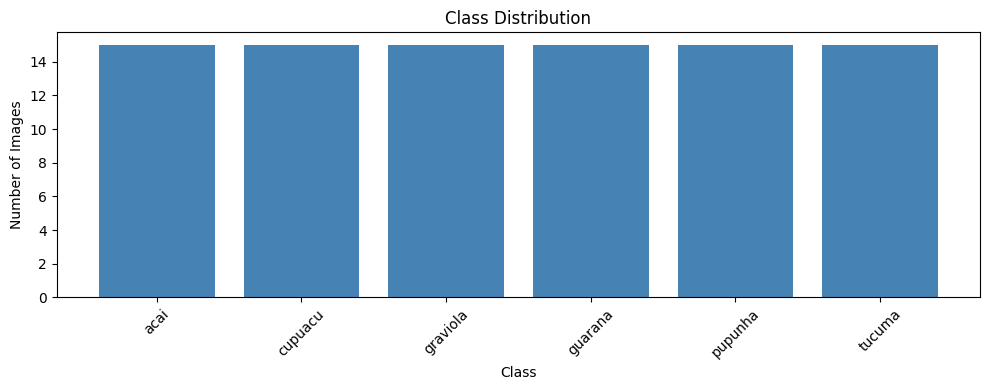

In [ ]:
"""Analyze and visualize class distribution."""

# Count images per class
CLASS_COUNTS = {}

for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        valid_images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        CLASS_COUNTS[class_name] = len(valid_images)

# Display class distribution table
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Image Count':>15}")
print("=" * 45)
for class_name, count in CLASS_COUNTS.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

# Visualize class distribution
plt.figure(figsize=(10, 4))
plt.bar(CLASS_COUNTS.keys(), CLASS_COUNTS.values(), color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 4: Select Random Images for Visualization

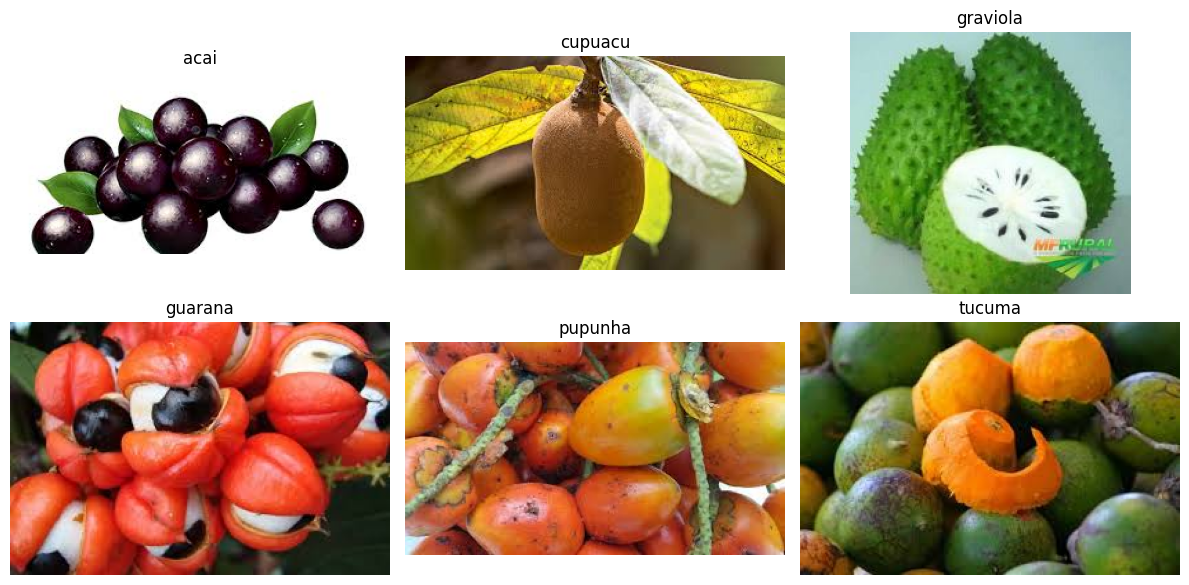

In [ ]:
"""Select and visualize sample images from each class."""

selected_images = []
selected_labels = []

# Select one random image from each class
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        valid_images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if valid_images:
            selected_img_name = random.choice(valid_images)
            selected_img_path = os.path.join(class_path, selected_img_name)
            selected_images.append(selected_img_path)
            selected_labels.append(class_name)

# Display images in grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for idx, ax in enumerate(axes.flat):
    if idx < num_classes:
        img = mpimg.imread(selected_images[idx])
        ax.imshow(img)
        ax.set_title(selected_labels[idx])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

---
## Section 2.2 - Data Generation and Pre-processing

In [ ]:
"""Create train/validation datasets with 80/20 split."""

# Dataset configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Generate datasets
TRAIN_DS, VAL_DS = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Display dataset information
print("Class names:", TRAIN_DS.class_names)
NUM_CLASSES = len(TRAIN_DS.class_names)
print(f"Number of classes: {NUM_CLASSES}")

# Check batch shape
for images, labels in TRAIN_DS.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Class names from dataset: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


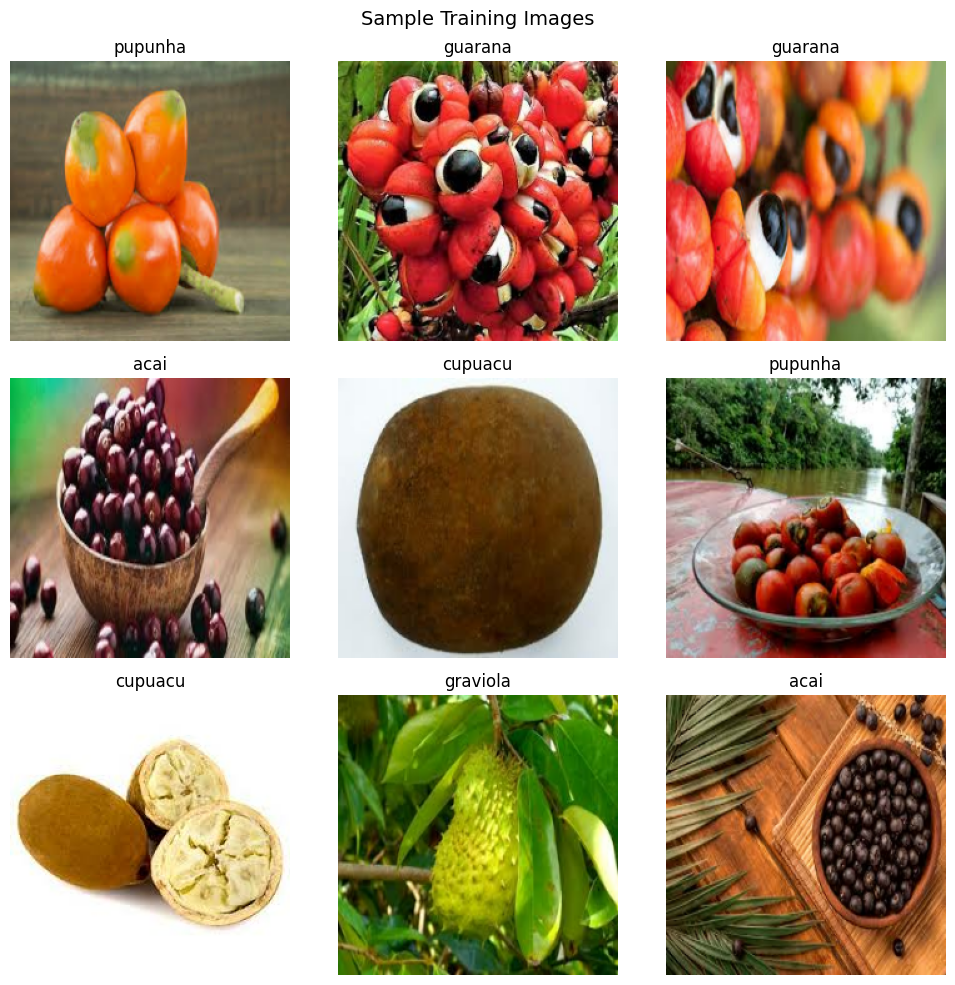

In [ ]:
"""Visualize a batch of training images."""

plt.figure(figsize=(10, 10))
for images, labels in TRAIN_DS.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(TRAIN_DS.class_names[int(labels[i])])
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

### Data Augmentation (New Keras API - Recommended)

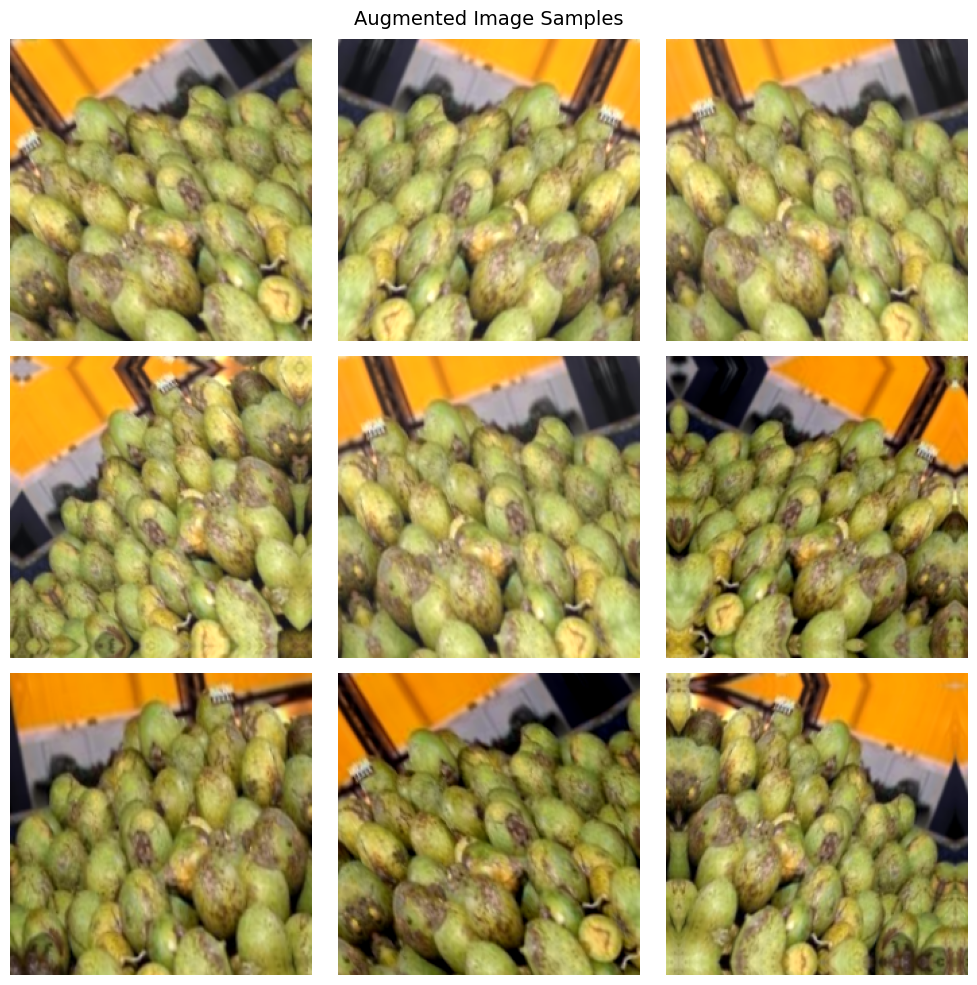

In [ ]:
"""Define and visualize data augmentation layers."""

# Data augmentation pipeline
DATA_AUGMENTATION_LAYERS = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
]


def apply_data_augmentation(images):
    """Apply data augmentation to a batch of images."""
    for layer in DATA_AUGMENTATION_LAYERS:
        images = layer(images)
    return images


# Visualize augmented images
plt.figure(figsize=(10, 10))
for images, _ in TRAIN_DS.take(1):
    for i in range(9):
        augmented_images = apply_data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

plt.suptitle("Augmented Image Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
"""Optimize datasets for training with caching and prefetching."""

AUTOTUNE = tf.data.AUTOTUNE
TRAIN_DS = TRAIN_DS.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
VAL_DS = VAL_DS.cache().prefetch(buffer_size=AUTOTUNE)

---
## Task 1: Improved CNN from Scratch with BatchNormalization and Dropout

In [ ]:
"""Build improved CNN model from scratch with BatchNormalization and Dropout."""

INPUT_SHAPE = (224, 224, 3)

# Build model using Sequential API
MODEL_SCRATCH = keras.Sequential([
    # Input and augmentation layers
    layers.Input(shape=INPUT_SHAPE),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Normalization
    layers.Rescaling(1.0 / 255),

    # Convolutional Block 1
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 2
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 3
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 4
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten and dense layers
    Flatten(),

    # Dense Block 1
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Dense Block 2
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Dense Block 3
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(NUM_CLASSES, activation='softmax'),
])

# Compile model
MODEL_SCRATCH.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

MODEL_SCRATCH.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
"""Train the CNN model from scratch."""

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define callbacks
EARLY_STOP = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)
REDUCE_LR = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

# Train model
EPOCHS = 30
HISTORY_SCRATCH = MODEL_SCRATCH.fit(
    TRAIN_DS,
    validation_data=VAL_DS,
    epochs=EPOCHS,
    callbacks=[EARLY_STOP, REDUCE_LR],
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1806 - loss: 2.5249 - val_accuracy: 0.2222 - val_loss: 1.7805 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.2361 - loss: 2.1543 - val_accuracy: 0.1667 - val_loss: 1.7923 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.3194 - loss: 2.0618 - val_accuracy: 0.1667 - val_loss: 1.8464 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.2222 - loss: 1.9370 - val_accuracy: 0.0556 - val_loss: 1.9306 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.2917 - loss: 1.8791 - val_accuracy: 0.0556 - val_loss: 2.0261 - learning_rate: 5.0000e-04
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3889 - loss: 1.6876 - val_accuracy: 0.0556 - val_loss: 2.1356 - learning_rate: 5.0000e-04


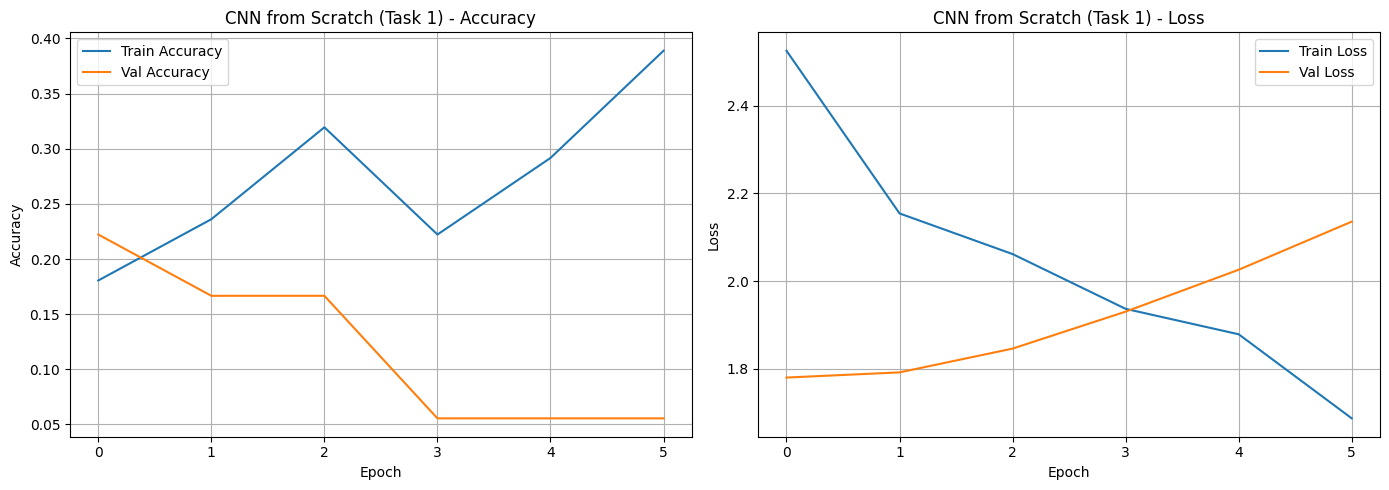

In [ ]:
"""Plot training history (accuracy and loss curves)."""


def plot_training_history(history, title='Model Training'):
    """
    Plot training and validation accuracy and loss.
    
    Args:
        history: Training history object from model.fit()
        title: Title for the plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


plot_training_history(HISTORY_SCRATCH, title='CNN from Scratch (Task 1)')

In [ ]:
"""Evaluate the trained CNN model on validation set."""

print("\n" + "=" * 50)
print("CNN from Scratch - Validation Evaluation")
print("=" * 50)

VAL_LOSS_SCRATCH, VAL_ACC_SCRATCH = MODEL_SCRATCH.evaluate(VAL_DS)
print(f"Validation Loss:     {VAL_LOSS_SCRATCH:.4f}")
print(f"Validation Accuracy: {VAL_ACC_SCRATCH:.4f}")


--- Task 1: CNN from Scratch Evaluation ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.2222 - loss: 1.7805
Validation Loss:     1.7805
Validation Accuracy: 0.2222



Classification Report - CNN from Scratch:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.29      0.80      0.42         5

    accuracy                           0.22        18
   macro avg       0.05      0.13      0.07        18
weighted avg       0.08      0.22      0.12        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


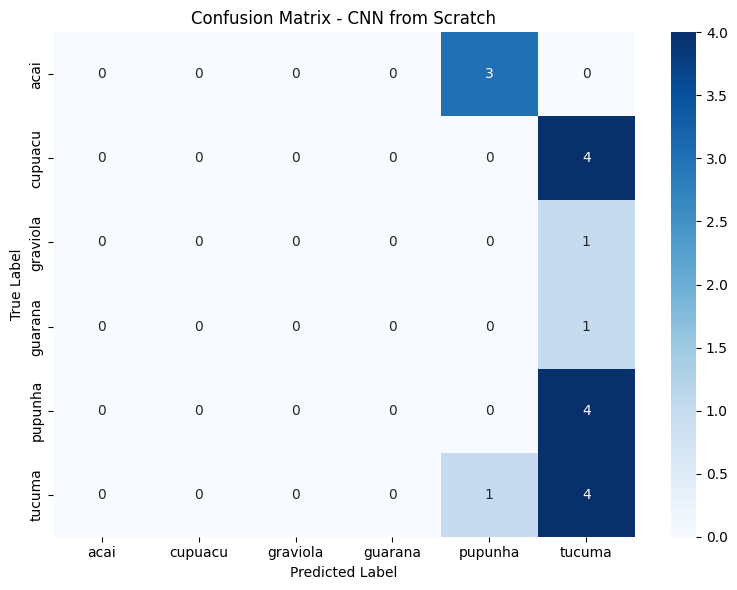

In [ ]:
"""Generate predictions and create confusion matrix."""

# Get predictions on validation set
Y_TRUE_SCRATCH = []
Y_PRED_SCRATCH = []

for images, labels in VAL_DS:
    preds = MODEL_SCRATCH.predict(images, verbose=0)
    Y_PRED_SCRATCH.extend(np.argmax(preds, axis=1))
    Y_TRUE_SCRATCH.extend(labels.numpy())

# Print classification report
print("\nClassification Report - CNN from Scratch:")
print(classification_report(
    Y_TRUE_SCRATCH,
    Y_PRED_SCRATCH,
    target_names=CLASS_NAMES,
))

# Create and visualize confusion matrix
CM_SCRATCH = confusion_matrix(Y_TRUE_SCRATCH, Y_PRED_SCRATCH)
plt.figure(figsize=(8, 6))
sns.heatmap(
    CM_SCRATCH,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Confusion Matrix - CNN from Scratch')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
"""Save the trained model."""

MODEL_SAVE_PATH = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/cnn_scratch_model.h5'
MODEL_SCRATCH.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Task 1 model saved as 'cnn_scratch_model.h5'


---
## Task 2: Transfer Learning with VGG16 (Fine-tuning)

In [ ]:
"""Load pre-trained VGG16 model without top layers."""

BASE_MODEL = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
)

print("VGG16 base model loaded.")
print(f"Total layers in VGG16: {len(BASE_MODEL.layers)}")
BASE_MODEL.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base model loaded.
Total layers in VGG16: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""Freeze all base model layers for transfer learning."""

for layer in BASE_MODEL.layers:
    layer.trainable = False

# Count trainable and frozen layers
trainable_count = sum(1 for layer in BASE_MODEL.layers if layer.trainable)
frozen_count = sum(1 for layer in BASE_MODEL.layers if not layer.trainable)

print(f"Trainable layers: {trainable_count}")
print(f"Frozen layers:    {frozen_count}")

Trainable layers: 0
Frozen layers:    19


In [ ]:
"""Build custom classifier on top of VGG16 base model."""

# Global average pooling
x = GlobalAveragePooling2D()(BASE_MODEL.output)

# Dense block 1
x = Dense(1024, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# Dense block 2
x = Dense(512, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# Output layer
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Create final model
MODEL_VGG16 = Model(inputs=BASE_MODEL.input, outputs=output)

# Display parameter counts
total_params = MODEL_VGG16.count_params()
trainable_params = sum(
    np.prod(v.shape) for v in MODEL_VGG16.trainable_variables
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     15,774,022
Trainable parameters: 1,056,262


In [ ]:
"""Compile VGG16 transfer learning model."""

MODEL_VGG16.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

MODEL_VGG16.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             

 Total params: 15,774,022 (60.17 MB)

 Trainable params: 1,056,262 (4.03 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

In [ ]:
"""Apply VGG16-specific preprocessing to datasets."""


def preprocess_for_vgg16(images, labels):
    """Apply VGG16 preprocessing (BGR and mean subtraction)."""
    return vgg16_preprocess(images), labels


# Apply preprocessing
TRAIN_DS_VGG = TRAIN_DS.map(preprocess_for_vgg16)
VAL_DS_VGG = VAL_DS.map(preprocess_for_vgg16)

print("Datasets preprocessed for VGG16.")

Datasets preprocessed for VGG16.


In [ ]:
"""Train VGG16 model with frozen base layers."""

# Define callbacks for VGG16
EARLY_STOP_VGG = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)
REDUCE_LR_VGG = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

# Train model
HISTORY_VGG16 = MODEL_VGG16.fit(
    TRAIN_DS_VGG,
    validation_data=VAL_DS_VGG,
    epochs=20,
    callbacks=[EARLY_STOP_VGG, REDUCE_LR_VGG],
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.2778 - loss: 1.9171 - val_accuracy: 0.5556 - val_loss: 1.2927 - learning_rate: 0.0010
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.7361 - loss: 0.7583 - val_accuracy: 0.6667 - val_loss: 1.2381 - learning_rate: 0.0010
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 11s/step - accuracy: 0.8889 - loss: 0.3614 - val_accuracy: 0.6111 - val_loss: 1.3244 - learning_rate: 0.0010
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 16s/step - accuracy: 0.9722 - loss: 0.1807 - val_accuracy: 0.6111 - val_loss: 1.3666 - learning_rate: 0.0010
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.9861 - loss: 0.0709 - val_accuracy: 0.6111 - val_loss: 1.3945 - learning_rate: 0.0010
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 13s/step - accuracy: 0.9861 - loss: 0.0841 - val_accuracy: 0.6111 - val_loss: 1.3839 - learning_rate: 5.0000e-04
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 19s/step - accuracy: 0.9861 - loss: 0.0794 - val_accuracy: 0.6

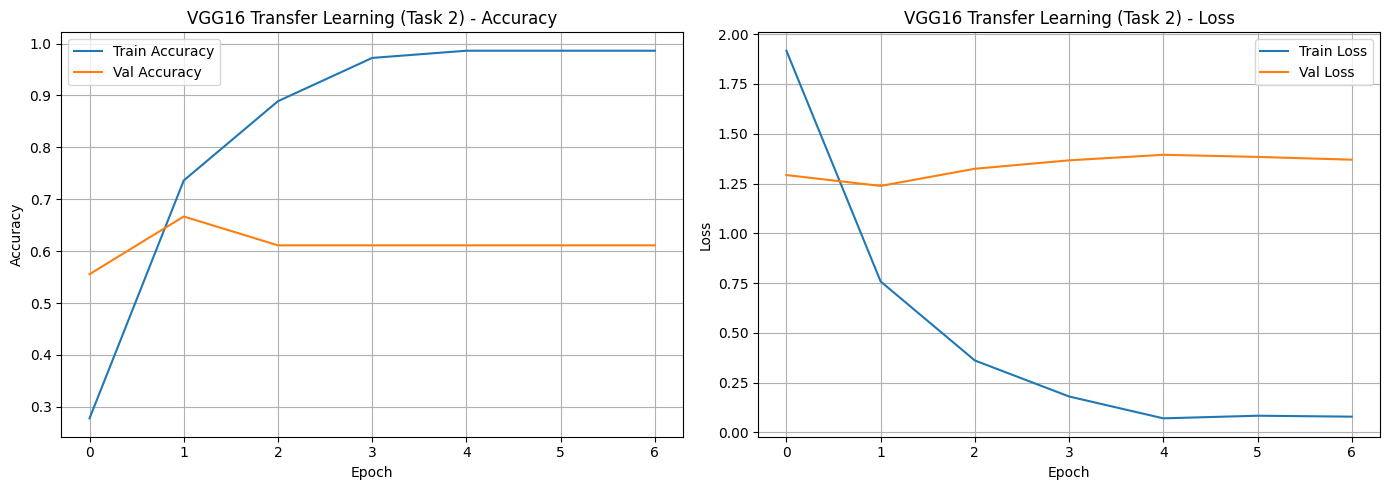

In [ ]:
"""Plot VGG16 training history."""

plot_training_history(HISTORY_VGG16, title='VGG16 Transfer Learning (Task 2)')

In [ ]:
"""Evaluate VGG16 model on validation set."""

print("\n" + "=" * 50)
print("VGG16 Transfer Learning - Validation Evaluation")
print("=" * 50)

VAL_LOSS_VGG, VAL_ACC_VGG = MODEL_VGG16.evaluate(VAL_DS_VGG)
print(f"Validation Loss:     {VAL_LOSS_VGG:.4f}")
print(f"Validation Accuracy: {VAL_ACC_VGG:.4f}")


--- Task 2: VGG16 Transfer Learning Evaluation ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.6667 - loss: 1.2381
Validation Loss:     1.2381
Validation Accuracy: 0.6667



Classification Report - VGG16 Transfer Learning:
              precision    recall  f1-score   support

        acai       0.50      0.67      0.57         3
     cupuacu       1.00      0.75      0.86         4
    graviola       1.00      1.00      1.00         1
     guarana       1.00      1.00      1.00         1
     pupunha       0.67      0.50      0.57         4
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.67        18
   macro avg       0.78      0.75      0.76        18
weighted avg       0.70      0.67      0.68        18



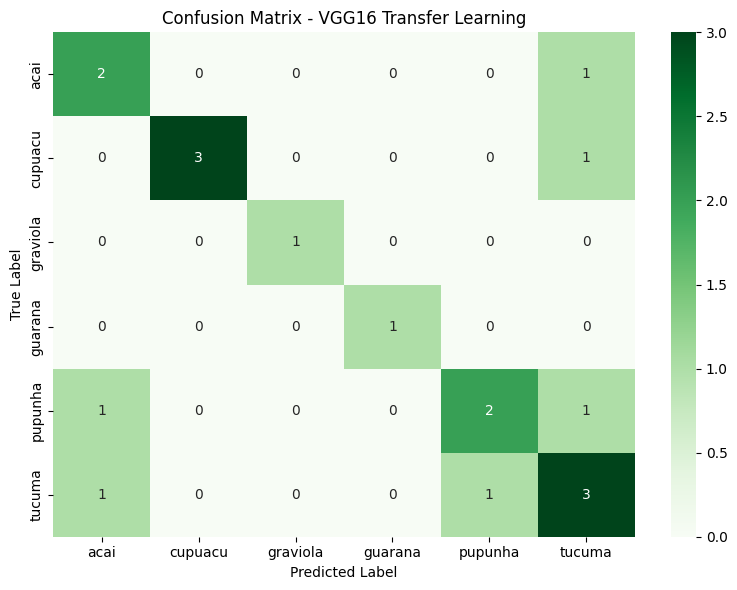

In [ ]:
"""Generate predictions and create confusion matrix for VGG16."""

# Get predictions
Y_PRED_VGG = []
Y_TRUE_VGG = []

for images, labels in VAL_DS_VGG:
    preds = MODEL_VGG16.predict(images, verbose=0)
    Y_PRED_VGG.extend(np.argmax(preds, axis=1))
    Y_TRUE_VGG.extend(labels.numpy())

# Print classification report
print("\nClassification Report - VGG16 Transfer Learning:")
print(classification_report(
    Y_TRUE_VGG,
    Y_PRED_VGG,
    target_names=CLASS_NAMES,
))

# Create and visualize confusion matrix
CM_VGG = confusion_matrix(Y_TRUE_VGG, Y_PRED_VGG)
plt.figure(figsize=(8, 6))
sns.heatmap(
    CM_VGG,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Confusion Matrix - VGG16 Transfer Learning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

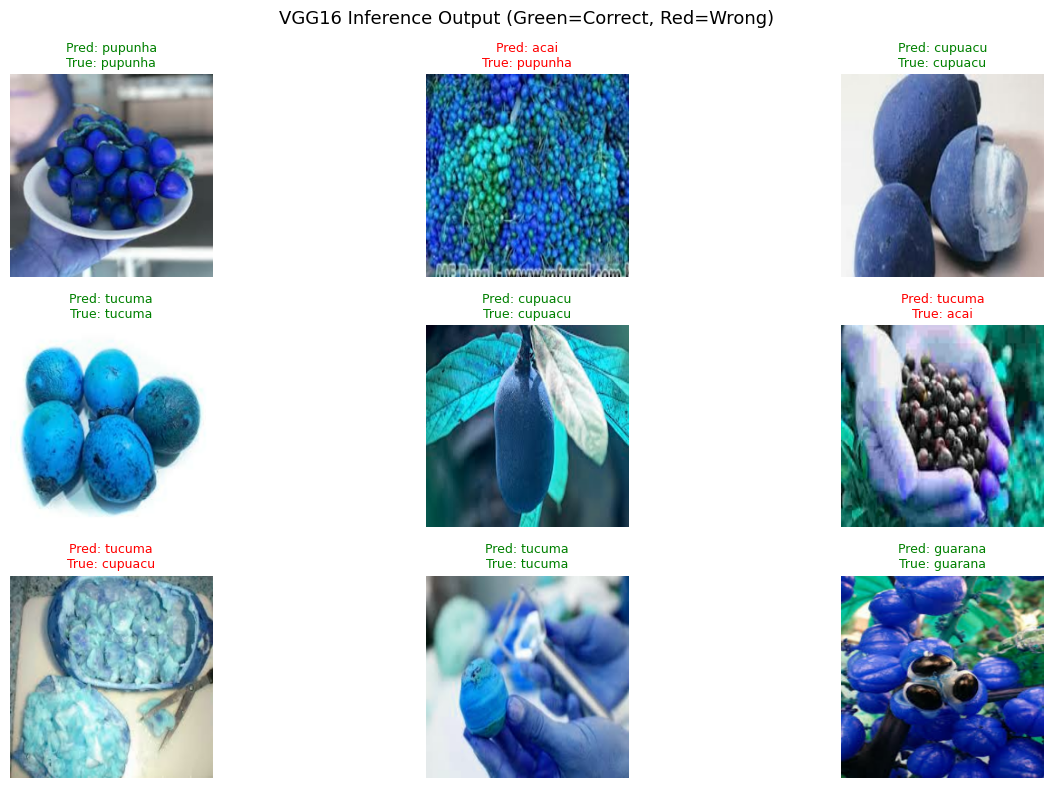

In [ ]:
"""Visualize inference results from validation set."""

plt.figure(figsize=(14, 8))

for images, labels in VAL_DS_VGG.take(1):
    preds = MODEL_VGG16.predict(images, verbose=0)
    
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        
        # Reverse VGG16 preprocessing for display
        raw_img = np.array(images[i] + [103.939, 116.779, 123.68])
        raw_img = np.clip(raw_img, 0, 255).astype('uint8')

        plt.imshow(raw_img)
        
        # Get predicted and true labels
        pred_label = CLASS_NAMES[np.argmax(preds[i])]
        true_label = CLASS_NAMES[int(labels[i])]
        color = 'green' if pred_label == true_label else 'red'
        
        plt.title(
            f"Pred: {pred_label}\nTrue: {true_label}",
            color=color,
            fontsize=9,
        )
        plt.axis('off')

plt.suptitle(
    "VGG16 Inference Output (Green=Correct, Red=Wrong)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

---
## Comparison: CNN from Scratch vs VGG16 Transfer Learning

In [ ]:
"""Compare performance of both models."""

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(
    f"{'Model':<35} {'Val Loss':>10} {'Val Accuracy':>12}"
)
print("-" * 60)
print(
    f"{'CNN from Scratch (Task 1)':<35} {VAL_LOSS_SCRATCH:>10.4f} "
    f"{VAL_ACC_SCRATCH:>11.4f}"
)
print(
    f"{'VGG16 Transfer Learning (Task 2)':<35} {VAL_LOSS_VGG:>10.4f} "
    f"{VAL_ACC_VGG:>11.4f}"
)
print("=" * 60)

# Compare accuracies
if VAL_ACC_VGG > VAL_ACC_SCRATCH:
    improvement = (VAL_ACC_VGG - VAL_ACC_SCRATCH) * 100
    print(f"\n✓ Transfer learning improved accuracy by {improvement:.2f}%")
else:
    difference = (VAL_ACC_SCRATCH - VAL_ACC_VGG) * 100
    print(f"\n✗ CNN from scratch performed better by {difference:.2f}%")
    print("  Consider fine-tuning more VGG16 layers or training longer.")


         MODEL PERFORMANCE COMPARISON
Model                            Val Loss   Val Accuracy
--------------------------------------------------
CNN from Scratch (Task 1)          1.7805        0.2222
VGG16 Transfer Learning (Task 2)     1.2381        0.6667

✅ Transfer Learning improved accuracy by 44.44%


In [ ]:
"""Save the VGG16 model."""

VGG_MODEL_SAVE_PATH = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-6/vgg16_transfer_model.h5'
MODEL_VGG16.save(VGG_MODEL_SAVE_PATH)
print(f"Model saved to: {VGG_MODEL_SAVE_PATH}")

Task 2 model saved as 'vgg16_transfer_model.h5'


---
## (Optional) Fine-tuning: Unfreeze top VGG16 layers for further improvement

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 13s/step - accuracy: 0.8750 - loss: 0.3269 - val_accuracy: 0.7222 - val_loss: 1.1186 - learning_rate: 1.0000e-05
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 13s/step - accuracy: 0.8889 - loss: 0.3170 - val_accuracy: 0.7222 - val_loss: 1.0301 - learning_rate: 1.0000e-05
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 86s 15s/step - accuracy: 0.9028 - loss: 0.3087 - val_accuracy: 0.6667 - val_loss: 0.9641 - learning_rate: 1.0000e-05
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 19s/step - accuracy: 0.8889 - loss: 0.2971 - val_accuracy: 0.6667 - val_loss: 0.9280 - learning_rate: 1.0000e-05
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 85s 21s/step - accuracy: 0.9583 - loss: 0.2491 - val_accuracy: 0.6667 - val_loss: 0.8993 - learning_rate: 1.0000e-05
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 13s/step - accuracy: 0.9167 - loss: 0.2872 - val_accuracy: 0.6667 - val_loss: 0.8712 - learning_rate: 1.0000e-05
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 85s 14s/step - accuracy: 0.9167 - loss: 0.2829

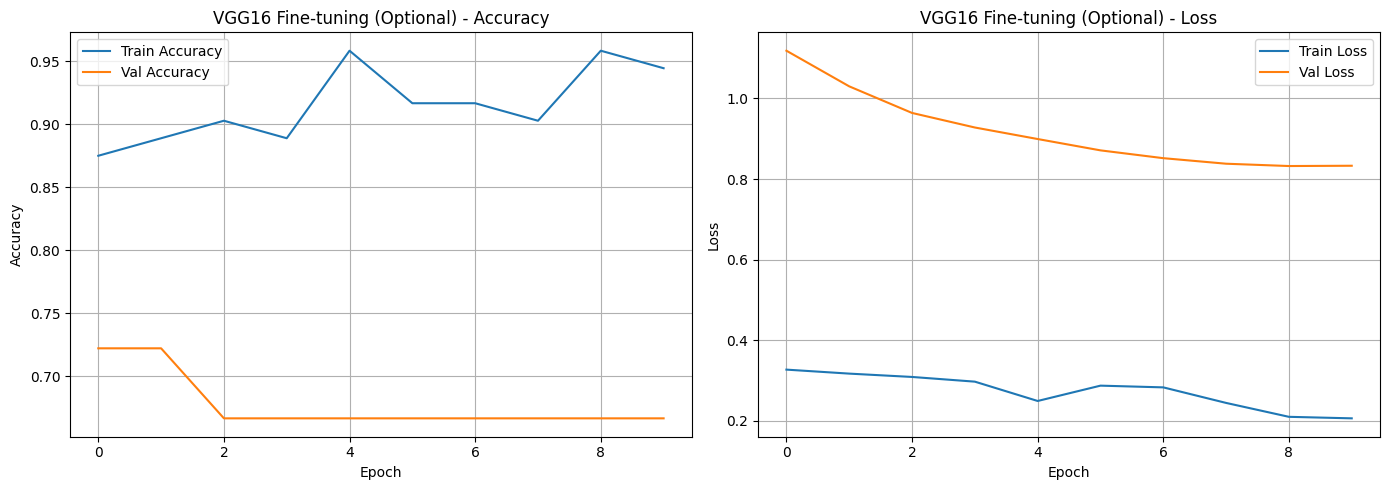

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.6667 - loss: 0.8323

Fine-tuned VGG16 - Val Loss: 0.8323, Val Accuracy: 0.6667


In [ ]:
"""Fine-tune top VGG16 layers for improved performance."""

# Unfreeze last 4 layers
for layer in BASE_MODEL.layers[-4:]:
    layer.trainable = True

# Recompile with lower learning rate
MODEL_VGG16.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Train with fine-tuning
FINE_TUNE_HISTORY = MODEL_VGG16.fit(
    TRAIN_DS_VGG,
    validation_data=VAL_DS_VGG,
    epochs=10,
    callbacks=[EARLY_STOP_VGG, REDUCE_LR_VGG],
)

plot_training_history(FINE_TUNE_HISTORY, title='VGG16 Fine-tuning')

# Evaluate fine-tuned model
FT_LOSS, FT_ACC = MODEL_VGG16.evaluate(VAL_DS_VGG)
print(
    f"\nFine-tuned VGG16 - "
    f"Val Loss: {FT_LOSS:.4f}, Val Accuracy: {FT_ACC:.4f}"
)